# Phase 2 - Shot Quality Model (xFG%)

Predicts the probability a field-goal attempt goes in. Feature engineering,
the time split, and the XGBoost model live in `src/phase2/shot_quality.py`;
this notebook reuses them.

**Data limitation (documented, not worked around):** the public
`shotchartdetail` endpoint has no defender-distance, shot-clock, or score-margin
fields, so the model relies on location, distance, shot type, zone, and clock.
That caps how good any public-data xFG% model can be.

Two outputs:
1. A shot chart colored by predicted make probability
2. A calibration curve

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
from sklearn.calibration import calibration_curve

from src.phase2.shot_quality import (
    build_features, time_split, train_model, evaluate,
    N_SEASONS, LAST_SEASON_START, N_TEST_SEASONS,
)
from src.ingest.nba_data import recent_seasons

seasons = recent_seasons(N_SEASONS, LAST_SEASON_START)
feats, feature_cols = build_features(seasons)
train, test, test_seasons = time_split(feats, N_TEST_SEASONS)
model = train_model(train, feature_cols)
test = test.copy()
test['pred'] = model.predict_proba(test[feature_cols])[:, 1]
print(f'Trained on {len(train):,} shots; testing on {test_seasons} ({len(test):,} shots).')

Trained on 409,600 shots; testing on ['2024-25'] (102,400 shots).


## 1. Shot chart colored by predicted make probability

Each point is a shot from the held-out test season, colored by the model's
predicted make probability. Green = high xFG% (at-rim), red = low (long jumpers).

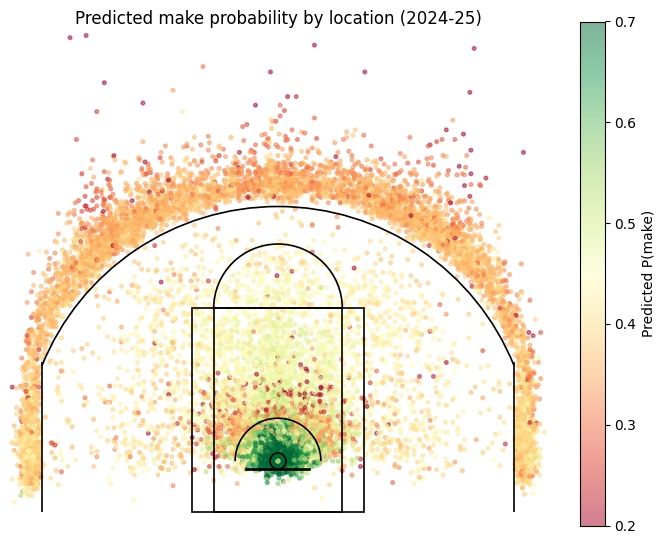

In [2]:
def draw_court(ax, color='black', lw=1.2):
    """Minimal half-court in nba_api shot units (tenths of a foot, hoop at 0,0)."""
    ax.add_patch(Circle((0, 0), 7.5, fill=False, color=color, lw=lw))          # hoop
    ax.add_patch(Rectangle((-30, -7.5), 60, -1, color=color, lw=lw))            # backboard
    ax.add_patch(Rectangle((-80, -47.5), 160, 190, fill=False, color=color, lw=lw))  # outer paint
    ax.add_patch(Rectangle((-60, -47.5), 120, 190, fill=False, color=color, lw=lw))  # inner paint
    ax.add_patch(Arc((0, 142.5), 120, 120, theta1=0, theta2=180, color=color, lw=lw))    # FT arc
    ax.add_patch(Arc((0, 0), 80, 80, theta1=0, theta2=180, color=color, lw=lw))          # restricted
    ax.add_patch(Rectangle((-220, -47.5), 0, 140, color=color, lw=lw))         # left corner 3
    ax.add_patch(Rectangle((220, -47.5), 0, 140, color=color, lw=lw))          # right corner 3
    ax.add_patch(Arc((0, 0), 475, 475, theta1=22, theta2=158, color=color, lw=lw))       # 3pt arc
    return ax

# Sample so the scatter stays readable.
plot_df = test.sample(min(15000, len(test)), random_state=0)
fig, ax = plt.subplots(figsize=(7, 6.6))
sc = ax.scatter(plot_df['loc_x'], plot_df['loc_y'], c=plot_df['pred'],
                cmap='RdYlGn', s=7, alpha=0.5, vmin=0.2, vmax=0.7)
draw_court(ax)
ax.set(xlim=(-250, 250), ylim=(-50, 400), aspect='equal',
       title=f'Predicted make probability by location ({test_seasons[0]})')
ax.axis('off')
fig.colorbar(sc, ax=ax, shrink=0.8, label='Predicted P(make)')
plt.tight_layout(); plt.show()

## 2. Calibration curve

Do predicted probabilities match observed make rates on the held-out season?

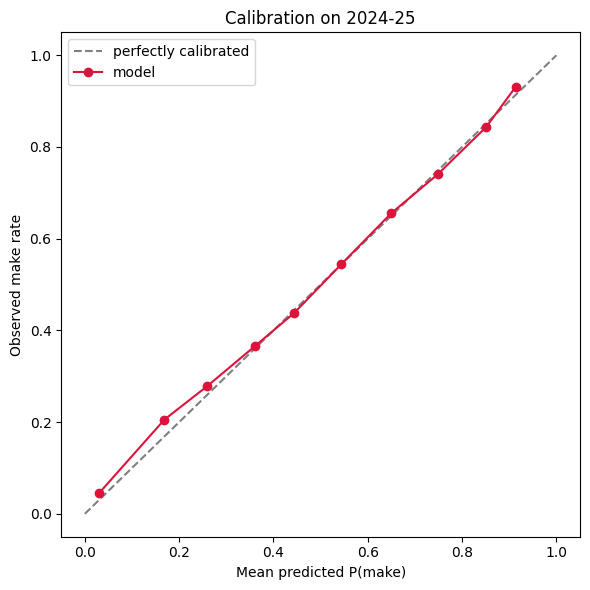


=== Shot quality model (XGBoost) ===
  train shots        : 409,600
  test shots         : 102,400
  league avg (train) : 0.4659
  log loss           : 0.6398   (baseline 0.6907)
  ROC-AUC            : 0.6566   (baseline 0.5000)
  top features (gain-weighted importance):
    SHOT_ZONE_BASIC_Restricted Area 0.6933
    action_grouped_Other         0.0654
    shot_distance                0.0500
    is_three                     0.0310
    action_grouped_Tip Layup Shot 0.0286
    action_grouped_Driving Layup Shot 0.0205
    action_grouped_Cutting Layup Shot 0.0168
    SHOT_ZONE_BASIC_Above the Break 3 0.0135


In [3]:
frac_pos, mean_pred = calibration_curve(test['target'], test['pred'], n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], ls='--', color='gray', label='perfectly calibrated')
plt.plot(mean_pred, frac_pos, marker='o', color='crimson', label='model')
plt.xlabel('Mean predicted P(make)'); plt.ylabel('Observed make rate')
plt.title(f'Calibration on {test_seasons[0]}'); plt.legend()
plt.tight_layout(); plt.show()

# Headline metrics next to the naive league-average baseline.
_ = evaluate(model, train, test, feature_cols)

## Takeaways

- Distance to the rim and shot zone (especially the restricted area) carry most
  of the signal; the model cleanly separates high-value at-rim shots from long
  jumpers.
- ROC-AUC in the mid-0.60s and log loss below the league-average baseline is a
  meaningful but modest lift - the honest ceiling for a model with no
  defender-distance or shot-clock information.